In [11]:
from langchain_groq import ChatGroq
from langchain_ollama import ChatOllama
from typing import TypedDict, Annotated
from langchain_core.messages import BaseMessage, HumanMessage
from langgraph.graph.message import add_messages
from langgraph.graph import StateGraph, START, END
from langgraph.checkpoint.memory import MemorySaver

In [25]:
llm = ChatGroq(model='openai/gpt-oss-120b', temperature=0.5, max_tokens=5000)
# llm = ChatOllama(model="qwen2.5:0.5b")

In [13]:
llm = ChatOllama(model='qwen3:1.7b')
llm.invoke('hi')

AIMessage(content='Hello! How can I assist you today? 😊 Let me know if you have any questions or need help with anything!', additional_kwargs={}, response_metadata={'model': 'qwen3:1.7b', 'created_at': '2026-05-06T08:59:32.647097261Z', 'done': True, 'done_reason': 'stop', 'total_duration': 4431718455, 'load_duration': 601556843, 'prompt_eval_count': 11, 'prompt_eval_duration': 185897075, 'eval_count': 100, 'eval_duration': 3589185267, 'logprobs': None, 'model_name': 'qwen3:1.7b', 'model_provider': 'ollama'}, id='lc_run--019dfc83-7a56-75e1-8563-73fbf7ccffa4-0', tool_calls=[], invalid_tool_calls=[], usage_metadata={'input_tokens': 11, 'output_tokens': 100, 'total_tokens': 111})

In [26]:
class ChatState(TypedDict):

    messages: Annotated[list[BaseMessage], add_messages]

In [27]:
async def chat_node(state: ChatState):

    # Take use query from state
    messages = state['messages']
    # send to llm
    response = await llm.ainvoke(messages)
    # response store
    return {'messages': [response]}

In [28]:
chekpointer = MemorySaver()
graph = StateGraph(ChatState)

# add nodes 
graph.add_node('chat_node', chat_node)

# add edges
graph.add_edge(START, 'chat_node')
graph.add_edge('chat_node', END)

chatbot = graph.compile(checkpointer=chekpointer)

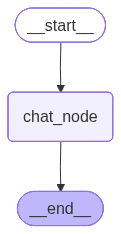

In [29]:
chatbot

In [30]:
initial_state = {
    'messages': [HumanMessage(content='What is the capital of pakistan?')]
}
# chatbot.invoke(initial_state)

In [32]:
thread_id = '1'
while True:

    user_message = input('Type here: ')
    print('User:', user_message)
    if user_message.strip().lower() in ['exit', 'quit', 'bye']:
        break 
    else: 
        config = {'configurable': {'thread_id': thread_id}}
        response = await chatbot.ainvoke({'messages':[HumanMessage(content=user_message)]}, config=config)        
        print('AI: ' , response['messages'][-1].content)

User: exit


In [33]:
chatbot.get_state(config=config)

StateSnapshot(values={'messages': [HumanMessage(content='write an essay on , how ai in changing the world , 2000 words essay', additional_kwargs={}, response_metadata={}, id='30f010d5-5340-4835-b4d2-21c543a5046b'), AIMessage(content='**How Artificial Intelligence Is Changing the World**  \n*An Approximate 2,000‑Word Essay*  \n\n---\n\n### Introduction  \n\nArtificial Intelligence (AI) has moved from the realm of speculative fiction into the fabric of everyday life. What began as a handful of research projects in the 1950s has, over the past two decades, blossomed into a global technological wave that reshapes economies, societies, and individual experiences. From voice assistants that answer our questions to sophisticated algorithms that predict disease outbreaks, AI is no longer a peripheral curiosity—it is a central driver of change.  \n\nThis essay explores the multifaceted ways AI is transforming the world. It examines the impact on **healthcare**, **education**, **the economy and 